In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, confusion_matrix, silhouette_score
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder

from xgboost import XGBClassifier
import optuna

/home/orlandojunior/miniconda3/envs/kaggle/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import kagglehub

# Download latest version
path = kagglehub.competition_download('playground-series-s6e6')

print("Path to competition files:", path)

Path to competition files: /home/orlandojunior/.cache/kagglehub/competitions/playground-series-s6e6


- spectral_type (tipo espectral) é uma classificação astronômica que agrupa as estrelas com base na temperatura da sua superfície e nas linhas de absorção do seu espectro de luz. A sequência oficial, da estrela mais quente para a mais fria, é memorizada pela clássica frase "Oh, Be A Fine Girl/Guy, Kiss Me": O, B, A, F, G, K, M.

- O termo ugriz (geralmente com apóstrofos: \(u', g', r', i', z'\)) designa um sistema de cinco filtros ópticos padronizados usados em telescópios, especialmente no Sloan Digital Sky Survey (SDSS). Cada letra isola uma faixa específica do espectro eletromagnético:
    - u: Ultravioleta (~355 nm)
    - g: Verde (green) (~470 nm)
    - r: Vermelho (red) (~615 nm)
    - i: Infravermelho (~750 nm)
    - z: Infravermelho distante (~890 nm)

- Redshift (ou desvio para o vermelho) é o estiramento das ondas de luz de objetos distantes causado pela expansão do universo. Como a luz viaja longas distâncias, ela se desloca para o lado vermelho do espectro. É uma medida direta da distância e da velocidade de afastamento de uma galáxia ou estrela

In [3]:
df_train = pd.read_csv(f'{path}/train.csv')
df_test = pd.read_csv(f'{path}/test.csv')
classes = df_train['class'].unique()

le = LabelEncoder()
le.fit(df_train['class'])
df_train['class'] = le.transform(df_train['class'])

ids = df_test['id']

In [4]:
def feature_engineering(df):
    df_fe = df.copy()
    
    df_fe['u_g'] = df_fe['u'] - df_fe['g']
    df_fe['g_r'] = df_fe['g'] - df_fe['r']
    df_fe['r_i'] = df_fe['r'] - df_fe['i']
    df_fe['i_z'] = df_fe['i'] - df_fe['z']
    df_fe['u_r'] = df_fe['u'] - df_fe['r']
    
    bands = ['u', 'g', 'r', 'i', 'z']
    df_fe['band_mean'] = df_fe[bands].mean(axis=1)
    df_fe['band_std']  = df_fe[bands].std(axis=1)
    df_fe['band_max']  = df_fe[bands].max(axis=1)
    df_fe['band_min']  = df_fe[bands].min(axis=1)
    df_fe['band_amp']  = df_fe['band_max'] - df_fe['band_min']
    
    df_fe['is_star_redshift'] = (df_fe['redshift'] < 0.01).astype(int)
    df_fe['is_qso_redshift'] = (df_fe['redshift'] > 1.5).astype(int)
    
    df_fe['redshift_x_band_mean'] = df_fe['redshift'] * df_fe['band_mean']
    
    alpha_rad = np.radians(df_fe['alpha'])
    delta_rad = np.radians(df_fe['delta'])
    
    df_fe['x_coord'] = np.cos(alpha_rad) * np.cos(delta_rad)
    df_fe['y_coord'] = np.sin(alpha_rad) * np.cos(delta_rad)
    df_fe['z_coord'] = np.sin(delta_rad)
    
    cols_to_remove = ['id']
    df_fe = df_fe.drop(columns=cols_to_remove)
    
    return df_fe

df_train = feature_engineering(df_train)
df_test = feature_engineering(df_test)
df = pd.concat([df_train,df_test], axis=0, sort=False)

In [5]:
df.info()

<class 'pandas.DataFrame'>
Index: 824782 entries, 0 to 247434
Data columns (total 27 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   alpha                 824782 non-null  float64
 1   delta                 824782 non-null  float64
 2   u                     824782 non-null  float64
 3   g                     824782 non-null  float64
 4   r                     824782 non-null  float64
 5   i                     824782 non-null  float64
 6   z                     824782 non-null  float64
 7   redshift              824782 non-null  float64
 8   spectral_type         824782 non-null  str    
 9   galaxy_population     824782 non-null  str    
 10  class                 577347 non-null  float64
 11  u_g                   824782 non-null  float64
 12  g_r                   824782 non-null  float64
 13  r_i                   824782 non-null  float64
 14  i_z                   824782 non-null  float64
 15  u_r             

In [6]:
df.head()

,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,...,band_std,band_max,band_min,band_amp,is_star_redshift,is_qso_redshift,redshift_x_band_mean,x_coord,y_coord,z_coord
0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,...,2.731221,25.472123,18.621057,6.851065,0,0,8.638015,-0.808809,0.510631,0.291692
1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,...,1.636652,20.778509,16.786433,3.992076,0,0,2.889860,-0.519995,0.665835,0.535041
2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,...,0.292103,21.171840,20.557366,0.614474,0,1,58.975095,-0.815680,0.002952,0.578496
3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,...,2.235331,23.305056,17.914952,5.390104,0,0,10.684892,-0.461171,-0.474536,0.749758
4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,...,1.676354,21.703158,17.616185,4.086973,0,0,10.551121,-0.741866,0.583034,0.331220


In [7]:
df.describe()

,alpha,delta,u,g,r,i,z,redshift,class,u_g,...,band_std,band_max,band_min,band_amp,is_star_redshift,is_qso_redshift,redshift_x_band_mean,x_coord,y_coord,z_coord
count,824782.000000,824782.000000,824782.000000,824782.000000,824782.000000,824782.000000,824782.000000,824782.000000,577347.000000,824782.000000,...,824782.000000,824782.000000,824782.000000,824782.000000,824782.000000,824782.000000,824782.000000,824782.000000,824782.000000,824782.000000
mean,181.539859,21.840427,22.441969,21.008043,19.963663,19.379796,19.041740,0.723629,0.489465,1.433926,...,1.432154,22.471955,18.991317,3.480638,0.037258,0.126899,15.181161,-0.165172,-0.021456,0.351113
std,96.234085,18.932900,2.018406,1.796388,1.649559,1.580605,1.585187,0.810224,0.732431,1.141746,...,0.769334,2.019351,1.553253,1.869143,0.189394,0.332860,17.266639,0.721666,0.491754,0.293862
min,0.010959,-17.966988,-0.139225,13.374549,10.390731,10.034180,10.632025,-0.009970,0.000000,-23.155858,...,0.014419,13.902664,-0.139225,0.039280,0.000000,0.000000,-0.225502,-0.999922,-0.985324,-0.308469
25%,132.094915,2.489501,20.977437,19.865342,18.824152,18.308940,17.974107,0.181672,0.000000,0.597867,...,0.710549,21.014561,17.942249,1.766324,0.000000,0.000000,3.490675,-0.698951,-0.458450,0.043436
50%,188.638826,21.466811,22.570080,21.468151,20.431239,19.631842,19.190919,0.497840,0.000000,1.332953,...,1.514898,22.613916,19.175678,3.626469,0.000000,0.000000,10.223826,-0.507537,-0.034249,0.365962
75%,231.810960,36.995129,23.869337,22.293241,21.164551,20.611005,20.163769,0.881655,1.000000,2.085966,...,1.992470,23.904356,20.107425,4.803673,0.000000,0.000000,18.861444,0.806664,0.417074,0.601747
max,359.999810,79.170436,28.253263,27.620208,25.291984,27.910853,26.826867,7.010780,2.000000,7.523080,...,9.596366,28.253263,23.364600,23.155858,1.000000,1.000000,162.045883,1.000000,0.999935,0.982190


In [8]:
object_cols = df.select_dtypes(include=['str']).columns
object_cols

Index(['spectral_type', 'galaxy_population'], dtype='str')

In [9]:
for col in object_cols:
    print(f'{col} - {df[col].unique()}')

spectral_type - <ArrowStringArray>
['M', 'O/B', 'G/K', 'A/F']
Length: 4, dtype: str
galaxy_population - <ArrowStringArray>
['Red_Sequence', 'Blue_Cloud']
Length: 2, dtype: str


<Axes: >

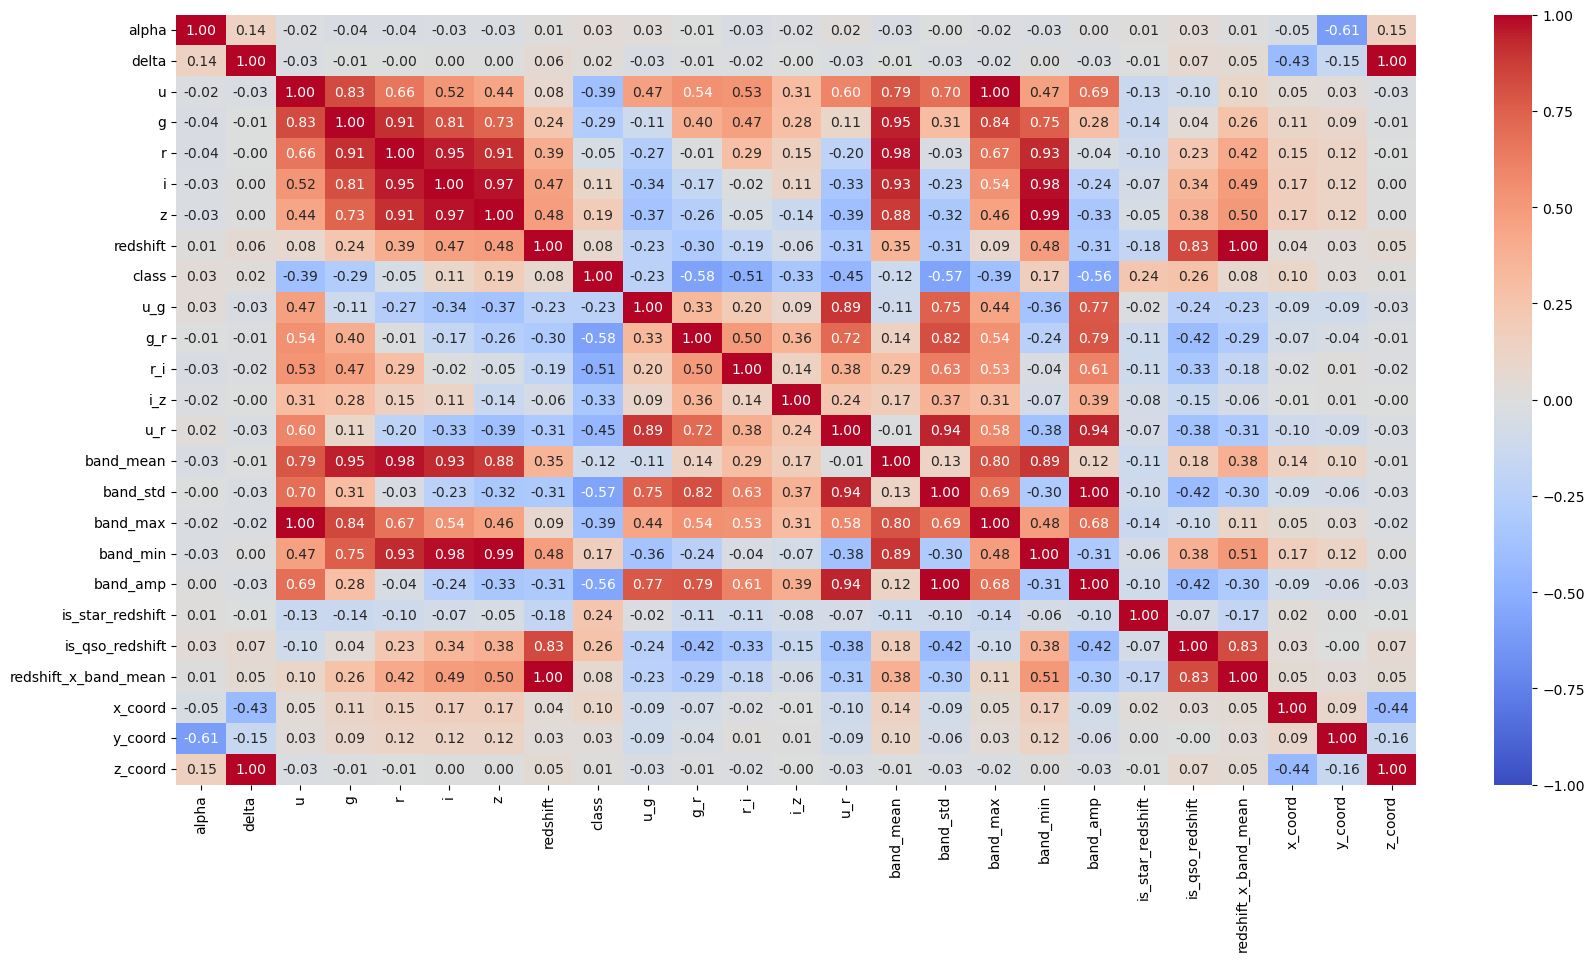

In [10]:
numeric_features = df.select_dtypes(include=['number']).columns
corr_mtx = df[numeric_features].corr()

plt.figure(figsize=(20,10))
sns.heatmap(
    corr_mtx,
    vmin=-1,
    vmax=1,
    cmap='coolwarm',
    annot=True,
    fmt='.2f'
)

In [11]:
corr_mtx['class'].sort_values(ascending=False)

class                   1.000000
is_qso_redshift         0.259106
is_star_redshift        0.236607
z                       0.190467
band_min                0.167940
i                       0.107635
x_coord                 0.102713
redshift                0.077758
redshift_x_band_mean    0.077461
alpha                   0.033585
y_coord                 0.027694
delta                   0.017359
z_coord                 0.014776
r                      -0.049845
band_mean              -0.115958
u_g                    -0.233462
g                      -0.285010
i_z                    -0.332746
u                      -0.385667
band_max               -0.386876
u_r                    -0.449060
r_i                    -0.507789
band_amp               -0.557203
band_std               -0.569432
g_r                    -0.583357
Name: class, dtype: float64

In [12]:
df['class'] = df['class'].fillna(0)

In [13]:
df['class'].isna().sum()

np.int64(0)

In [14]:
numeric_features

Index(['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift', 'class', 'u_g',
       'g_r', 'r_i', 'i_z', 'u_r', 'band_mean', 'band_std', 'band_max',
       'band_min', 'band_amp', 'is_star_redshift', 'is_qso_redshift',
       'redshift_x_band_mean', 'x_coord', 'y_coord', 'z_coord'],
      dtype='str')

In [15]:
numeric = ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift', 'u_g',
       'g_r', 'r_i', 'i_z', 'u_r', 'band_mean', 'band_std', 'band_max',
       'band_min', 'band_amp','redshift_x_band_mean', 'x_coord', 'y_coord', 'z_coord']
cols_to_onehot = ['spectral_type', 'galaxy_population']

preprocess = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(),numeric),
        ('cat', OneHotEncoder(handle_unknown='ignore',sparse_output=False),cols_to_onehot)
    ],
    remainder='passthrough'
)

df_processed = preprocess.fit_transform(df)
names = preprocess.get_feature_names_out()

df = pd.DataFrame(df_processed, columns=names)



In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 824782 entries, 0 to 824781
Data columns (total 31 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   num__alpha                           824782 non-null  float64
 1   num__delta                           824782 non-null  float64
 2   num__u                               824782 non-null  float64
 3   num__g                               824782 non-null  float64
 4   num__r                               824782 non-null  float64
 5   num__i                               824782 non-null  float64
 6   num__z                               824782 non-null  float64
 7   num__redshift                        824782 non-null  float64
 8   num__u_g                             824782 non-null  float64
 9   num__g_r                             824782 non-null  float64
 10  num__r_i                             824782 non-null  float64
 11  num__i_z                

In [17]:
df.head()

,num__alpha,num__delta,num__u,num__g,num__r,num__i,num__z,num__redshift,num__u_g,num__g_r,...,num__z_coord,cat__spectral_type_A/F,cat__spectral_type_G/K,cat__spectral_type_M,cat__spectral_type_O/B,cat__galaxy_population_Blue_Cloud,cat__galaxy_population_Red_Sequence,remainder__class,remainder__is_star_redshift,remainder__is_qso_redshift
0,-0.351285,-0.257814,1.501261,0.494056,0.239012,-0.077618,-0.265384,-0.388346,1.876633,0.670146,...,-0.202208,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
1,-0.556468,0.554923,-0.824146,-1.069358,-1.440661,-1.362598,-1.422740,-0.698145,0.225550,0.618820,...,0.625901,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
2,-0.018156,0.713278,-0.696969,0.039571,0.732425,0.760996,0.956119,2.592053,-1.294379,-1.544885,...,0.773776,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0
3,0.460112,1.411776,0.427608,0.023766,-0.573432,-0.641614,-0.710824,-0.231455,0.718543,1.343142,...,1.356574,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
4,-0.412575,-0.131917,-0.366037,-0.855252,-1.048289,-0.936571,-0.899299,-0.207187,0.698537,0.262013,...,-0.067695,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0


In [18]:
features_numeric = df.select_dtypes(include=['number']).columns
features_numeric

Index(['num__alpha', 'num__delta', 'num__u', 'num__g', 'num__r', 'num__i',
       'num__z', 'num__redshift', 'num__u_g', 'num__g_r', 'num__r_i',
       'num__i_z', 'num__u_r', 'num__band_mean', 'num__band_std',
       'num__band_max', 'num__band_min', 'num__band_amp',
       'num__redshift_x_band_mean', 'num__x_coord', 'num__y_coord',
       'num__z_coord', 'cat__spectral_type_A/F', 'cat__spectral_type_G/K',
       'cat__spectral_type_M', 'cat__spectral_type_O/B',
       'cat__galaxy_population_Blue_Cloud',
       'cat__galaxy_population_Red_Sequence', 'remainder__class',
       'remainder__is_star_redshift', 'remainder__is_qso_redshift'],
      dtype='str')

In [19]:
training = df[:df_train.shape[0]]
testing = df[df_train.shape[0]:]

In [20]:
testing = testing.drop(columns='remainder__class')

In [21]:
X = training.drop(columns='remainder__class')
y = training['remainder__class']

In [22]:
# cluster_range = range(2, 11)
# cluster_sample_size = min(120000, len(X))
# X_cluster_sample = X.sample(n=cluster_sample_size, random_state=42)

# silhouette_scores = []

# for k in cluster_range:
#     km_tmp = KMeans(n_clusters=k, random_state=0, n_init="auto")
#     labels_tmp = km_tmp.fit_predict(X_cluster_sample)

#     score = silhouette_score(
#         X_cluster_sample,
#         labels_tmp,
#         sample_size=min(10000, len(X_cluster_sample)),
#         random_state=42,
#     )
#     silhouette_scores.append(score)
#     print(f"k={k} | silhouette={score:.4f}")

# best_n_clusters = list(cluster_range)[np.argmax(silhouette_scores)]
# print(f"\nMelhor numero de clusters (silhouette): {best_n_clusters}")

# plt.figure(figsize=(8, 4))
# plt.plot(list(cluster_range), silhouette_scores, marker="o")
# plt.xlabel("Numero de clusters (k)")
# plt.ylabel("Silhouette medio")
# plt.title("Analise de silhouette para KMeans")
# plt.grid(alpha=0.3)
# plt.show()
# # Melhor resultado= 3

In [23]:

kmeans = KMeans(n_clusters=3, random_state=0, n_init="auto")
X['cluster'] = kmeans.fit_predict(X)

testing['cluster'] = kmeans.predict(testing)

In [24]:
X_train, X_temp, y_train ,y_temp = train_test_split(X,y, test_size=0.2, random_state=0,shuffle=True,stratify=y)
X_test, X_val, y_test ,y_val = train_test_split(X_temp,y_temp, test_size=0.5, random_state=0,shuffle=True,stratify=y_temp)

X_train.shape, X_test.shape, X_val.shape 

((461877, 31), (57735, 31), (57735, 31))

In [25]:
# def objective(trial):
#     params = {
#         "n_estimators": trial.suggest_int("n_estimators", 200, 1200),
#         "max_depth": trial.suggest_int("max_depth", 3, 10),
#         "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.2, log=True),
#         "subsample": trial.suggest_float("subsample", 0.6, 1.0),
#         "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
#         "random_state": 42,
#         "eval_metric": "mlogloss",
#     }
#     model = XGBClassifier(**params)
#     score = cross_val_score(model, X_train, y_train, cv=3, scoring="accuracy").mean()
#     return score

# study = optuna.create_study(
#     direction="maximize",
#     study_name="xgb_tuning",
# )

# study.optimize(objective, n_trials=30)
# print("Melhor score:", study.best_value)
# print("Melhores params:", study.best_params)

In [26]:
best_model = XGBClassifier(
    n_estimators = 1039, 
    max_depth= 9, 
    learning_rate= 0.06389394853982121, 
    subsample= 0.9621953616612997, 
    colsample_bytree= 0.8151200401732903,
    random_state=42,
    eval_metric="mlogloss"
)

best_model.fit(X_train, y_train)
preds = best_model.predict(X_test)

In [27]:
print(classification_report(y_test,preds))

              precision    recall  f1-score   support

         0.0       0.98      0.98      0.98     37748
         1.0       0.97      0.96      0.97     11714
         2.0       0.93      0.93      0.93      8273

    accuracy                           0.97     57735
   macro avg       0.96      0.96      0.96     57735
weighted avg       0.97      0.97      0.97     57735



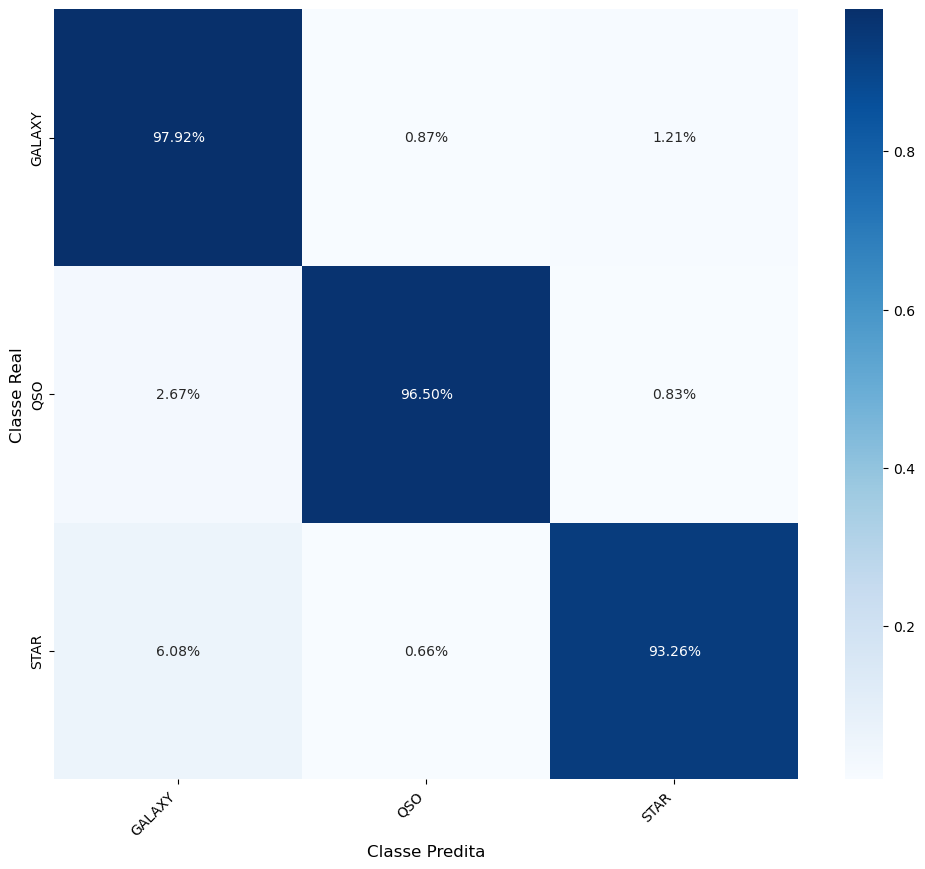

In [28]:
cm = confusion_matrix(y_test, preds, normalize='true')

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='.2%', cmap='Blues', 
            xticklabels=classes, 
            yticklabels=classes)

plt.ylabel('Classe Real', fontsize=12)
plt.xlabel('Classe Predita', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.show()


In [29]:
preds

array([0, 0, 0, ..., 0, 0, 0], shape=(57735,))

In [30]:
preds_final = best_model.predict(testing)

preds_label = le.inverse_transform(preds_final)

df_final = pd.DataFrame({'id': ids, 'class': preds_label})
df_final.head()

,id,class
0,577347,GALAXY
1,577348,GALAXY
2,577349,GALAXY
3,577350,STAR
4,577351,GALAXY


In [31]:
df_final.to_csv('submission.csv',index=False)

accuracy 0.97

cm: 
- GALAXY: 97.92

- QSO: 96.50

- STAR: 93.26